#**Movie Recommendation System**

Recommendation systems are among the most impactful applications of machine learning, powering content discovery across streaming platforms, e-commerce, and social media. At their core, they solve a fundamental information retrieval problem: given a large catalogue of items and a user with unknown preferences over most of them, identify the subset most likely to be relevant.

This project implements a movie recommendation engine from scratch using the [MovieLens](https://grouplens.org/datasets/movielens/) dataset, comprising over 33 million ratings across 86,000 movies by 330,000 users. Four distinct algorithms are implemented, each representing a different paradigm for modelling user-item affinity:

* **Content-Based Filtering** recommends items similar to those a user has liked, based on item metadata (genres and tags), without requiring any knowledge of other users.

* **User-Based Collaborative Filtering** identifies users with similar rating patterns and leverages their preferences to generate recommendations.

* **Item-Based Collaborative Filtering** finds items that tend to be rated similarly across the user base and recommends items similar to those already liked by the target user.

* **UV Decomposition (Matrix Factorisation)** learns latent representations of users and items by factorising the rating matrix, capturing hidden preference structure not directly observable in the raw ratings.

All four models are implemented as Python classes mirroring the design conventions of standard ML libraries. This makes them modular, comparable, and straightforward to deploy.

The project covers the full pipeline: data acquisition and preprocessing, exploratory data analysis, model implementation, and systematic evaluation using rating accuracy metrics (RMSE, MAE) and ranking metrics (Precision@10, Recall@10, nDCG@10) on a held-out test set.

In [ ]:
# Load Dependencies

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import io
import requests
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent / 'src'))
from content_model import ContentBasedRecommender
from user_model import UserBasedCF
from item_model import ItemBasedCF
from uv_model import UVDecomposition
from evaluation import RecommenderEvaluator
import joblib

In [ ]:
# Download zip

url = 'https://files.grouplens.org/datasets/movielens/ml-latest.zip'
response = requests.get(url)
zip_file = zipfile.ZipFile(io.BytesIO(response.content))

In [ ]:
# Import Data

ratings = pd.read_csv(zip_file.open('ml-latest/ratings.csv'))
movies = pd.read_csv(zip_file.open('ml-latest/movies.csv'))
tags = pd.read_csv(zip_file.open('ml-latest/genome-tags.csv'))
scores = pd.read_csv(zip_file.open('ml-latest/genome-scores.csv'))

In [ ]:
# Filter Dataset

min_ratings = 100
ratings['timestamp'] = pd.to_datetime(ratings['timestamp'], unit='s')
filtered_ratings = ratings.copy()

while True:
    initial_rows = filtered_ratings.shape[0]

    movie_counts = filtered_ratings['movieId'].value_counts()
    popular_movies = movie_counts[movie_counts >= min_ratings].index
    filtered_ratings = filtered_ratings[filtered_ratings['movieId'].isin(popular_movies)]

    user_counts = filtered_ratings['userId'].value_counts()
    active_users = user_counts[user_counts >= min_ratings].index
    filtered_ratings = filtered_ratings[filtered_ratings['userId'].isin(active_users)]

    if filtered_ratings.shape[0] == initial_rows:
        break

print('Filtered Ratings:', len(filtered_ratings))
print('Filtered Users:', filtered_ratings['userId'].nunique())
print('Filtered Movies:', filtered_ratings['movieId'].nunique())

Filtered Ratings: 25942777
Filtered Users: 81612
Filtered Movies: 11943


We apply an iterative co-filtering procedure, retaining only users and movies with at least 100 ratings. A single-pass filter is insufficient as removing low-activity users may drop a movie below the threshold, and vice versa, so the filter is applied alternately until the dataset stabilises. This eliminates cold-start entities with unreliable similarity estimates while preserving a dense, statistically meaningful core. After filtering, the dataset reduces from 33.8M to 26M ratings, from 331K to 81.6K users, and from 86K to 12K movies, retaining roughly 77% of all ratings.

## Exploratory Data Analysis

In [ ]:
# Data shape

print('The ratings DataFrame shape is:', ratings.shape)
print('The movies DataFrame shape is:',movies.shape)
print('The tags DataFrame shape is:',tags.shape)
print('The scores DataFrame shape is:',scores.shape)

The ratings DataFrame shape is: (33832162, 4)
The movies DataFrame shape is: (86537, 3)
The tags DataFrame shape is: (1128, 2)
The scores DataFrame shape is: (18472128, 3)


In [ ]:
# Movies DataFrame

movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86537 entries, 0 to 86536
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  86537 non-null  int64 
 1   title    86537 non-null  object
 2   genres   86537 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.0+ MB


The movies dataset consists of 3 columns: **movieId**, **title**, and **genres**

In [ ]:
# Ratings DataFrame

ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33832162 entries, 0 to 33832161
Data columns (total 4 columns):
 #   Column     Dtype         
---  ------     -----         
 0   userId     int64         
 1   movieId    int64         
 2   rating     float64       
 3   timestamp  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(2)
memory usage: 1.0 GB


The ratings dataset consists of 4 columns: **userId**, **movieId**, **rating**, and **timestamp**.

In [ ]:
# Tags DataFrame

tags.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1128 entries, 0 to 1127
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   tagId   1128 non-null   int64 
 1   tag     1128 non-null   object
dtypes: int64(1), object(1)
memory usage: 17.8+ KB


The movies dataset consists of 2 columns: **tagId**, and **tag**

In [ ]:
# Scores DataFrame

scores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18472128 entries, 0 to 18472127
Data columns (total 3 columns):
 #   Column     Dtype  
---  ------     -----  
 0   movieId    int64  
 1   tagId      int64  
 2   relevance  float64
dtypes: float64(1), int64(2)
memory usage: 422.8 MB


The ratings dataset consists of 3 columns: **movieId**, **tagId**, and **relevance**

In [ ]:
# Inspect movies

movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [ ]:
# Inspect ratings

ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,2008-11-03 17:52:19
1,1,110,4.0,2008-11-05 06:04:46
2,1,158,4.0,2008-11-03 17:31:43
3,1,260,4.5,2008-11-03 18:00:04
4,1,356,5.0,2008-11-03 17:58:39


In [ ]:
# Inspect tags

tags.head()

,tagId,tag
0,1,007
1,2,007 (series)
2,3,18th century
3,4,1920s
4,5,1930s


In [ ]:
# Inspect scores

scores.head()

,movieId,tagId,relevance
0,1,1,0.03200
1,1,2,0.02225
2,1,3,0.07000
3,1,4,0.05900
4,1,5,0.12300


In [ ]:
# Health Checks

print('Ratings Nulls:', sum(ratings.isnull().sum()))
print('Movies Nulls:', sum(movies.isnull().sum()))
print('Tags Nulls:', sum(tags.isnull().sum()))
print('Scores Nulls:', sum(scores.isnull().sum()))
print('Ratings Duplicates:', ratings.duplicated().sum())
print('Movies Duplicates:', movies.duplicated().sum())
print('Tags Duplicates:', tags.duplicated().sum())
print('Scores Duplicates:', scores.duplicated().sum())

Ratings Nulls: 0
Movies Nulls: 0
Tags Nulls: 0
Scores Nulls: 0
Ratings Duplicates: 0
Movies Duplicates: 0
Tags Duplicates: 0
Scores Duplicates: 0


The data are clean. No null values or duplicate records, so no imputation or deduplication is required before proceeding.

In [ ]:
# Temporal split 80/20

ratings_sorted = filtered_ratings.sort_values(by=['userId', 'timestamp']).reset_index(drop=True)
ratings_sorted['user_total'] = ratings_sorted.groupby('userId')['userId'].transform('count')
ratings_sorted['user_rank']  = ratings_sorted.groupby('userId').cumcount() + 1
train_mask = ratings_sorted['user_rank'] <= (ratings_sorted['user_total'] * 0.8)
train = ratings_sorted[train_mask].drop(columns=['user_total', 'user_rank'])
test  = ratings_sorted[~train_mask].drop(columns=['user_total', 'user_rank'])

print('Train shape:', train.shape)
print('Test shape:', test.shape)
print('Unique users in Train:', train['userId'].nunique())
print('Unique users in Test: ', test['userId'].nunique())

Train shape: (20721823, 4)
Test shape: (5220954, 4)
Unique users in Train: 81612
Unique users in Test:  81612


The dataset is split 80/20 into training and test sets. The training set (≈20.7M ratings) is used exclusively for model fitting, while the test set (≈5.2M ratings) is held out and used only for final evaluation. A temporal split is used to simulate realistic deployment conditions: the model is trained on each user's earlier ratings and evaluated on their later ones, preventing future data from leaking into training and ensuring metrics reflect genuine predictive performance

In [ ]:
# Train data Overview

print('Unique Users:', train['userId'].nunique())
print('Unique Movies:', train['movieId'].nunique())
print('Total ratings:', len(train['rating']))
print('Global Average rating:', round(train['rating'].mean(), 2))
print('Rating Scale:', train['rating'].min(), '-', train['rating'].max())
print('Average number of ratings per user:', round(len(train['rating'])/train['userId'].nunique(), 2))
print('Average number of ratings per movie:', round(len(train['rating'])/train['movieId'].nunique(), 2))

Unique Users: 81612
Unique Movies: 11943
Total ratings: 20721823
Global Average rating: 3.52
Rating Scale: 0.5 - 5.0
Average number of ratings per user: 253.91
Average number of ratings per movie: 1735.06


The training set contains 81,612 unique users who rated 11,943 unique movies, producing 20,721,823 ratings in total. Ratings range from 0.5 to 5.0 with a global mean of 3.5, reflecting the positive selection bias inherent in explicit feedback datasets, users tend to rate items they chose to watch and expected to enjoy, skewing the distribution upward. On average, each user has rated 254 movies and each movie has received 1,735 ratings, consistent with the 100-rating filter applied during preprocessing.

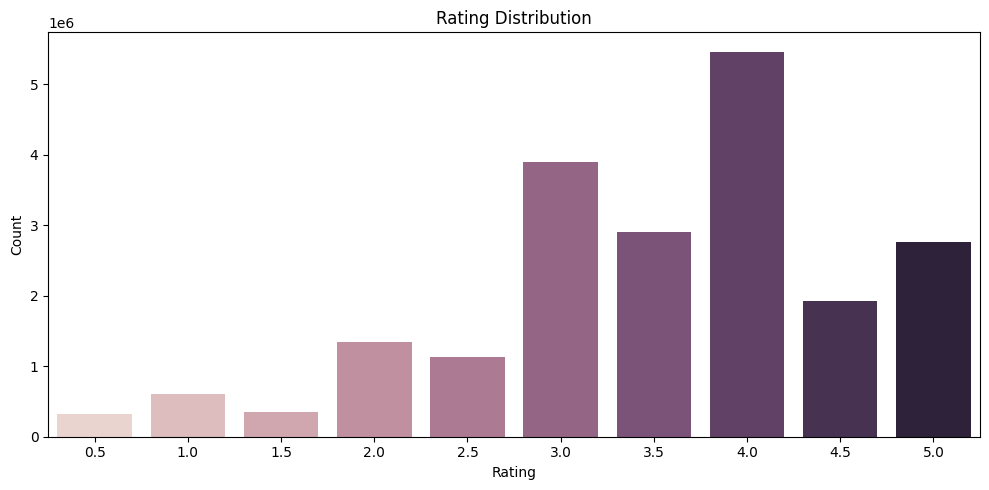

In [ ]:
# Rating Distribution

rating_counts = train['rating'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
sns.barplot(x=rating_counts.index, y=rating_counts.values, hue=rating_counts.index, legend=False)
plt.xlabel('Rating')
plt.ylabel('Count')
plt.title('Rating Distribution')
plt.tight_layout()
plt.show()

The rating distribution confirms the positive selection bias noted earlier. Ratings are left-skewed with the vast majority falling at 3.0 or above. 4.0 is the most frequent value at over 5 million ratings, followed by 3.0 at roughly 4 million. Half-star ratings are consistently less common than their adjacent whole-star values, suggesting users favour round numbers. Ratings of 1.5 and below are rare, reinforcing that users predominantly rate content they chose to engage with and found at least moderately worthwhile.

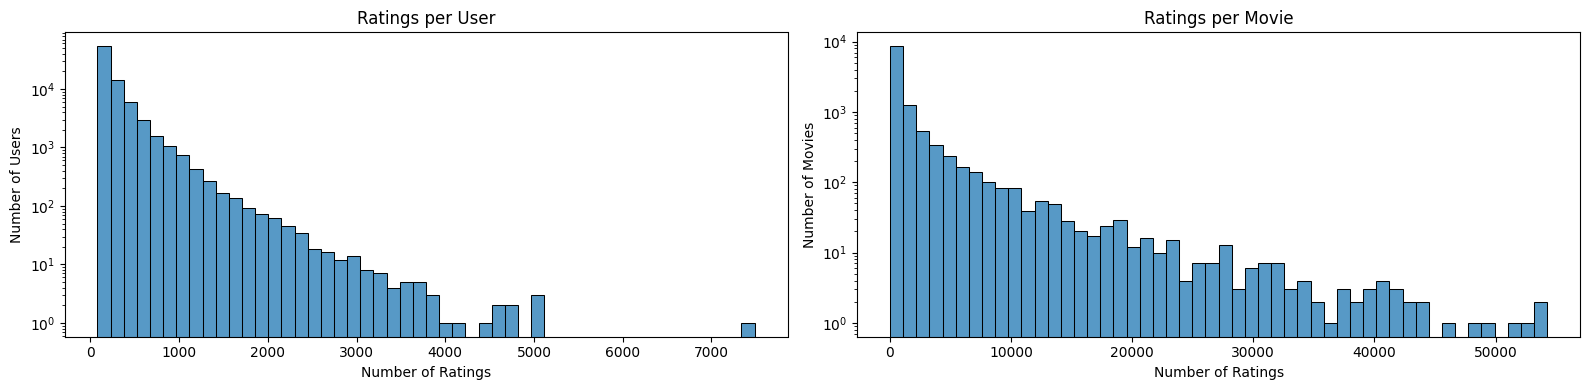

In [ ]:
# Ratings per user

user_ratings = train.groupby('userId')['rating'].count()

plt.figure(figsize=(16,4))
plt.subplot(1, 2, 1)
sns.histplot(user_ratings, bins = 50)
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Users')
plt.title('Ratings per User')
plt.yscale('log')

# Ratings per movie

movie_ratings = train.groupby('movieId')['rating'].count()

plt.subplot(1, 2, 2)
sns.histplot(movie_ratings, bins = 50)
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Movies')
plt.title('Ratings per Movie')
plt.yscale('log')
plt.tight_layout()
plt.show()

The majority of users have rated between 100 and 500 movies, with the count dropping sharply beyond that. A small number of highly active users have rated over 3,000 movies. The movie distribution tells the same story as most movies sit near the 100-rating floor imposed by the filter, while a handful of titles accumulate tens of thousands of ratings.

In [ ]:
# Top 5 Most Rated Movies

top_movies = train.merge(movies, on='movieId')
top_movies['title'].value_counts().head(5)

,count
title,
"Matrix, The (1999)",54263
Forrest Gump (1994),53790
Pulp Fiction (1994),52560
"Shawshank Redemption, The (1994)",51735
"Silence of the Lambs, The (1991)",48986


**The Matrix**, **Forrest Gump**, **Pulp Fiction**, **The Shawshank Redemption** and **The Silence of the Lambs** are the movies with the most ratings.

In [ ]:
# Highest/Lowest average rating

movie_stats  = train.groupby('movieId')['rating'].mean()

low_rating = movie_stats.idxmin()
high_rating = movie_stats.idxmax()

print('Movie with the lowest average rating:', movies[movies['movieId'] == low_rating]['title'].values[0])
print('Movie with the highest average rating:', movies[movies['movieId'] == high_rating]['title'].values[0])

Movie with the lowest average rating: SuperBabies: Baby Geniuses 2 (2004)
Movie with the highest average rating: Planet Earth II (2016)


 **SuperBabies: Baby Geniuses 2** emerges as the lowest rated movie, while **Planet Earth II** holds the highest average rating

In [ ]:
# Movie Genres
movies['genres'] = movies['genres'].fillna('').astype(str)
movies['genres'] = movies['genres'].str.split('|')
movies['genres'].head()

,genres
0,"[Adventure, Animation, Children, Comedy, Fantasy]"
1,"[Adventure, Children, Fantasy]"
2,"[Comedy, Romance]"
3,"[Comedy, Drama, Romance]"
4,[Comedy]


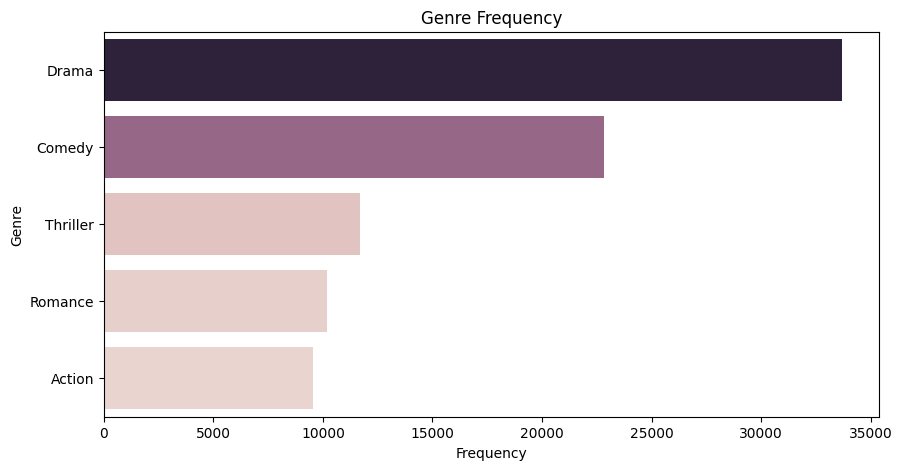

In [ ]:
# Genre Frequency

genre_freq = movies['genres'].explode().value_counts().head()

plt.figure(figsize=(10,5))
sns.barplot(x=genre_freq.values, y=genre_freq.index, hue=genre_freq.values, legend=False)
plt.xlabel('Frequency')
plt.ylabel('Genre')
plt.title('Genre Frequency')
plt.show()

The most common genres are **Drama**, **Comedy**, **Thriller**, **Romance** and **Action**.

In [ ]:
# Utility Matrix Sparsity

n_users = filtered_ratings['userId'].nunique()
n_movies = filtered_ratings['movieId'].nunique()
n_ratings = len(filtered_ratings)
sparsity = 1 - (n_ratings/(n_users*n_movies))
print(f'Utility Matrix Sparsity: {sparsity:.4f}')

Utility Matrix Sparsity: 0.9734


The utility matrix spans 81,612 users and 11,943 movies, yielding roughly 974 million possible user-movie pairs. With 25.9 million observed ratings, the matrix is 97.34% sparse, meaning only 2.66% of entries are filled. This level of sparsity is typical of real-world rating datasets and is the fundamental challenge that recommender systems must overcome.

Despite this, the 100-rating filter applied during preprocessing ensures that no user or movie enters the matrix with fewer than 100 observations. This means there are no completely cold entities as every row and every column has sufficient signal for similarity computation.

## Content-Based Filtering

The content-based model builds a profile for each user from the metadata of movies they have rated. Movie metadata is constructed by combining genre labels with genome tag scores, retaining only tags with a relevance score of 0.5 or above. This corpus is vectorised using TF-IDF, producing a sparse item matrix where each movie is represented by a weighted term vector. A user profile is then computed as a weighted sum of the TF-IDF vectors of rated movies, where the weights are the mean-centred ratings. Positively rated movies pull the profile toward their content, negatively rated ones push away. At inference time, recommendations are generated by computing cosine similarity between the user profile and all unrated item vectors, scaled to the rating range using the training set standard deviation.

In [ ]:
# Content model fit

content_model = ContentBasedRecommender()
content_model.fit(train, movies, tags, scores)

In [ ]:
# Serialize content model

joblib.dump(content_model, '../api/content_model.joblib')

['content_model.joblib']

In [ ]:
# Sample recommendation

sample_user = int(train['userId'].iloc[0])
recommendations_content = content_model.recommend(sample_user)
print(f'Top 10 recommendations for user {sample_user}:')
print(recommendations_content)

Top 10 recommendations for user 7:
                        title  predicted_rating
0                Katyn (2007)             3.650
1   Watch on the Rhine (1943)             3.640
2         Mrs. Miniver (1942)             3.626
3             Blue Sky (1994)             3.623
4  Twelve O'Clock High (1949)             3.623
5            Cavalcade (1933)             3.622
6        Alvarez Kelly (1966)             3.619
7  Great Ziegfeld, The (1936)             3.618
8  Deluge, The (Potop) (1974)             3.613
9       Iron Lady, The (2011)             3.613


## User-Based Collaborative Filtering

The user-based model identifies users with similar rating patterns and aggregates their ratings to predict how the target user would rate unseen items. The rating matrix is stored as a sparse CSR matrix. For a given user, cosine similarity is computed against all other users. Only neighbours above a similarity threshold of 0.3 are considered, capped at the top 100. Predictions are computed as the target user's mean rating adjusted by a similarity-weighted average of neighbours' mean-centred ratings, which corrects for individual rating scale differences.

In [ ]:
# User model fit

user_model = UserBasedCF()
user_model.fit(train, movies)

In [ ]:
# Serialize user model

joblib.dump(user_model, '../api/user_model.joblib')

['user_model.joblib']

In [ ]:
# Sample recommendation

sample_user = int(train['userId'].iloc[0])
recommendations_user = user_model.recommend(sample_user)
print(f'Top 10 recommendations for user {sample_user}:')
print(recommendations_user)

Top 10 recommendations for user 7:
                                              title  predicted_rating
0                     It Came from Hollywood (1982)             4.681
1                          Shadow of a Doubt (1943)             4.626
2                  Shawshank Redemption, The (1994)             4.551
3  Himalaya (Himalaya - l'enfance d'un chef) (1999)             4.537
4                              Before Sunset (2004)             4.534
5                              Kolya (Kolja) (1996)             4.499
6                               Big One, The (1997)             4.459
7                            Planet Earth II (2016)             4.448
8                               Planet Earth (2006)             4.429
9                                          M (1931)             4.427


## Item-Based Collaborative Filtering

The item-based model computes similarity between items based on how users have co-rated them. For a target user-item pair, the model identifies items the user has already rated, computes cosine similarity between those items and the target item, and produces a prediction as the target item's mean rating adjusted by a similarity-weighted average of the user's mean-centred ratings on similar items. The same neighbour threshold and cap apply as in the user-based model.

In [ ]:
# Item model fit

item_model = ItemBasedCF()
item_model.fit(train, movies)

In [ ]:
# Serialize item model

joblib.dump(item_model, '../api/item_model.joblib')

['item_model.joblib']

In [ ]:
# Sample recommendation

sample_user = int(train['userId'].iloc[0])
recommendations_item = item_model.recommend(sample_user)
print(f'Top 10 recommendations for user {sample_user}:')
print(recommendations_item)

Top 10 recommendations for user 7:
                                               title  predicted_rating
0                           Finding Forrester (2000)             5.000
1                         Fiddler on the Roof (1971)             5.000
2  Monty Python's And Now for Something Completel...             5.000
3                              Mister Roberts (1955)             5.000
4                                 Holiday Inn (1942)             5.000
5                       American in Paris, An (1951)             5.000
6                             White Christmas (1954)             4.986
7                              Guys and Dolls (1955)             4.958
8                        Meet Me in St. Louis (1944)             4.935
9                        Bend It Like Beckham (2002)             4.877


## UV-decomposition

UV decomposition factorises the rating matrix into two lower-dimensional dense matrices: a user factor matrix P and an item factor matrix Q, each with 15 latent dimensions. The predicted rating for a user-item pair is the dot product of their respective factor vectors. Both matrices are learned via mini-batch stochastic gradient descent with L2 regularisation, shuffling the training data each epoch. Training runs for up to 50 epochs with early stopping when the observed MSE falls below 0.55

In [ ]:
# UV model fit

uv_model = UVDecomposition()
uv_model.fit(train, movies)

Epoch 01/50, observed MSE: 1.5018
Epoch 02/50, observed MSE: 0.8449
Epoch 03/50, observed MSE: 0.7743
Epoch 04/50, observed MSE: 0.7473
Epoch 05/50, observed MSE: 0.7339
Epoch 06/50, observed MSE: 0.7265
Epoch 07/50, observed MSE: 0.7220
Epoch 08/50, observed MSE: 0.7191
Epoch 09/50, observed MSE: 0.7171
Epoch 10/50, observed MSE: 0.7154
Epoch 11/50, observed MSE: 0.7136
Epoch 12/50, observed MSE: 0.7114
Epoch 13/50, observed MSE: 0.7082
Epoch 14/50, observed MSE: 0.7039
Epoch 15/50, observed MSE: 0.6984
Epoch 16/50, observed MSE: 0.6924
Epoch 17/50, observed MSE: 0.6868
Epoch 18/50, observed MSE: 0.6817
Epoch 19/50, observed MSE: 0.6773
Epoch 20/50, observed MSE: 0.6735
Epoch 21/50, observed MSE: 0.6701
Epoch 22/50, observed MSE: 0.6669
Epoch 23/50, observed MSE: 0.6640
Epoch 24/50, observed MSE: 0.6610
Epoch 25/50, observed MSE: 0.6580
Epoch 26/50, observed MSE: 0.6549
Epoch 27/50, observed MSE: 0.6515
Epoch 28/50, observed MSE: 0.6481
Epoch 29/50, observed MSE: 0.6444
Epoch 30/50, o

In [ ]:
# Serialize UV model

joblib.dump(uv_model, '../api/uv_model.joblib')

['uv_model.joblib']

In [ ]:
# Sample recommendation

sample_user = int(train['userId'].iloc[0])
recommendations_uv = uv_model.recommend(sample_user)
print(f'Top 10 recommendations for user {sample_user}:')
print(recommendations_uv)

Top 10 recommendations for user 7:
                                               title  predicted_rating
0                   Shawshank Redemption, The (1994)             4.079
1         Spider-Man: Across the Spider-Verse (2023)             4.038
2                          The Wild Pear Tree (2018)             4.036
3  Human Condition III, The (Ningen no joken III)...             3.990
4                        Cosmos: A Spacetime Odissey             3.949
5                               Magnetic Rose (1995)             3.915
6                            Band of Brothers (2001)             3.911
7                                Planet Earth (2006)             3.891
8                                 Bitter Lake (2015)             3.891
9                                  Wild China (2008)             3.882


## Evaluation

The RecommenderEvaluator class handles prediction in batches of 100,000 pairs to keep memory usage tractable and computes five metrics across two categories:

**Rating Accuracy** measures how closely predicted ratings match actual ratings at the individual pair level. RMSE penalises large errors more heavily due to squaring, making it sensitive to outliers, while MAE treats all errors equally and is more interpretable as an average absolute deviation in rating units.

**Ranking Quality** measures how well each model orders items for a given user. Precision@10 is the fraction of the top-10 recommended items that are relevant, where relevance is defined as a rating of 3.5 or above. Recall@10 is the fraction of all relevant items in the test set that appear in the top-10. nDCG@10 (Normalised Discounted Cumulative Gain) extends precision by accounting for position — a relevant item ranked first contributes more than one ranked tenth — and normalises against the ideal ranking, producing a score between 0 and 1 where 1 is perfect ordering.

Together these metrics capture complementary aspects of recommender performance: a model can achieve low RMSE by predicting ratings accurately without necessarily ranking the best items at the top, and vice versa.

In [ ]:
# Model Evaluation

evaluator = RecommenderEvaluator(test)

In [ ]:
# Content based eval

content_results = evaluator.full_evaluation(content_model)
print(content_results)

{'RMSE': 0.946, 'MAE': 0.712, 'Precision@10': 0.764, 'Recall@10': 0.302, 'nDCG@10': 0.845}


In [ ]:
# User based eval

user_results = evaluator.full_evaluation(user_model)
print(user_results)

{'RMSE': 0.842, 'MAE': 0.633, 'Precision@10': 0.804, 'Recall@10': 0.324, 'nDCG@10': 0.871}


In [ ]:
# Item based eval

item_results = evaluator.full_evaluation(item_model)
print(item_results)

{'RMSE': 0.877, 'MAE': 0.659, 'Precision@10': 0.791, 'Recall@10': 0.318, 'nDCG@10': 0.86}


In [ ]:
# UV decomposition eval

uv_results = evaluator.full_evaluation(uv_model)
print(uv_results)

{'RMSE': 0.795, 'MAE': 0.598, 'Precision@10': 0.819, 'Recall@10': 0.332, 'nDCG@10': 0.881}


In [ ]:
results = pd.DataFrame([content_results, user_results, item_results, uv_results])
results.index = ['Content-Based', 'User-Based', 'Item-Based', 'UV-Decomposition']
results.columns = ['RMSE', 'MAE', 'Precision@10', 'Recall@10', 'nDCG@10']
results

,RMSE,MAE,Precision@10,Recall@10,nDCG@10
Content-Based,0.946,0.712,0.764,0.302,0.845
User-Based,0.842,0.633,0.804,0.324,0.871
Item-Based,0.877,0.659,0.791,0.318,0.860
UV-Decomposition,0.795,0.598,0.819,0.332,0.881


**Rating accuracy (RMSE, MAE)**

UV delivers the best pointwise prediction, which is expected since matrix factorisation learns a  low-rank approximation of the rating matrix that generalises better than neighbourhood averages. Item-based CF sits between user-based and content, which reflects that item similarities on explicit dense data are noisier than user similarities as items get rated by heterogeneous audiences whereas users have coherent taste profiles. Content being last is structural, not a failure because it predicts from metadata alone with zero knowledge of how users actually rated.

**Ranking quality (Precision@10, Recall@10, nDCG@10)**

The ordering mirrors accuracy exactly, which is not guaranteed because a model can predict ratings accurately but rank poorly or vice versa. The fact that UV dominates both dimensions simultaneously indicates the latent factors capture preference structure useful for both tasks. The high absolute values across all models (Precision@10 above 0.76 everywhere) reflect the filtered dense population where every model has abundant signal.

**Overall**

Across all five metrics the ranking is consistent: UV Decomposition leads, followed by User-Based, Item-Based, and Content-Based. This ordering makes intuitive sense since the more a model knows about how users collectively behave, the better it performs, with the content model working blind to that information and UV capturing the deepest patterns in the data. The high scores across the board reflect the fact that we are evaluating on a dense, active subset of the dataset where every model has plenty to work with. Within that context, the results are clean, coherent, and confirm that each algorithm does exactly what it is designed to do.